# Knowledge Graph Features for Machine Learning

**Chapter 23: Knowledge Graphs for Financial AI** | Section 23.4

**Docker image**: `ml4t`

> **Neo4j required**: This notebook queries a Neo4j graph database.
> Start Neo4j first, then run the notebook:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t python 23_knowledge_graphs/09_knowledge_graph_features.py
> ```


This notebook transforms the chapter's real knowledge-graph artifacts into
ML-ready features. It combines the supply chain graph loaded into Neo4j by
`02_supply_chain_kg_construction.py` with the Chapter 4 institutional holdings
parquet files to produce a feature matrix for downstream modeling.

**Learning Objectives**:
- Compute network topology features from a real supply chain graph
- Derive supplier concentration and competitive exposure indicators
- Build institutional crowding signals from real 13F holdings
- Construct cross-graph features that combine operational and ownership risk
- Output a feature matrix in wide and long formats for downstream ML

**Book Reference**: Chapter 23, Section 23.4 (From Graphs to Machine Learning Features)

**Prerequisites**: Run `02_supply_chain_kg_construction.py` first to populate Neo4j
and ensure the 13F parquet artifacts exist under `data/equities/positioning/13f`
(produced by `data/equities/positioning/13f_download.py`).

In [1]:
"""Knowledge Graph Features for Machine Learning - transform KG artifacts into ML-ready features."""

from __future__ import annotations

import json
import os
from datetime import date
from hashlib import sha256
from logging import getLogger

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap

from data import load_institutional_holdings_13f
from utils.paths import get_chapter_dir, get_output_dir
from utils.style import add_message_title, ml4t_diverging, show_with_alt

getLogger("matplotlib.font_manager").setLevel("ERROR")

In [2]:
# Production defaults - Papermill overrides for testing
N_COMPANIES = 0  # 0 = all available
# Point-in-time as-of date for holdings-derived features. Empty resolves to the
# date the newest complete 13F report period became public, read off the artifact
# below. An earlier override is honoured; a later one has no data behind it.
CUTOFF_DATE = ""
# 02_supply_chain_kg_construction records the graph it wrote under this name.
SUPPLY_SNAPSHOT_NAME = "ch23_supply_chain"

In [3]:
OUTPUT_DIR = get_output_dir(23, "knowledge_graph_features")
print(f"Output target: {OUTPUT_DIR.name}")

Output target: knowledge_graph_features


In [4]:
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

### Name Normalization

Cross-dataset joins (supply-chain company names vs 13F issuer names) need a
canonical form. This collapses case, punctuation, and common corporate suffixes
(CORPORATION→CORP, INCORPORATED→INC) to a single comparable token.

In [5]:
def normalize_name(value: str) -> str:
    """Normalize names for cross-dataset joins."""
    aliases = {
        "LABORATORIES": "LABS",
        "LABORATORY": "LAB",
        "CORPORATION": "CORP",
        "COMPANY": "CO",
        "INCORPORATED": "INC",
    }
    tokens = []
    for token in "".join(ch if ch.isalnum() else " " for ch in value.upper()).split():
        tokens.append(aliases.get(token, token))
    return "".join(tokens)

## 1. Load the Real Supply Chain Graph

Pull the supply chain graph directly from Neo4j. The notebook requires the
real graph built in the previous case-study notebook rather than constructing
a synthetic network inline.

In [6]:
COMPANY_QUERY = """
MATCH (c:Company)
WHERE EXISTS { MATCH (c)-[:HAS_SUPPLIER|COMPETES_WITH|HAS_CUSTOMER]->() }
RETURN DISTINCT c.name AS company
ORDER BY company
"""
RELATIONSHIP_QUERY = """
    CALL () {
        MATCH (c:Company)-[:HAS_SUPPLIER]->(s:Supplier)
        RETURN c.name AS company, 'HAS_SUPPLIER' AS predicate, s.name AS related
        UNION ALL
        MATCH (c:Company)-[:COMPETES_WITH]->(peer:Company)
        RETURN c.name AS company, 'COMPETES_WITH' AS predicate, peer.name AS related
        UNION ALL
        MATCH (c:Company)-[:HAS_CUSTOMER]->(cust:Customer)
        RETURN c.name AS company, 'HAS_CUSTOMER' AS predicate, cust.name AS related
    }
    RETURN company, predicate, related
    ORDER BY company, predicate, related
"""

### The Snapshot Guard

The graph this notebook reads has to be the one `02_supply_chain_kg_construction`
wrote, not what a partial run or a different revision left behind. 02 records the
identity of the graph as it read it back: the sha256 of the sorted relationship
lines, the per-class edge counts, the company count, and the content hash of the
extraction cache it loaded. This notebook queries the graph independently and
compares.

Both reads come out of the same database, so agreement alone would only show the
graph has not changed since 02 ran. The cache hash is what ties it to something
outside: the sidecar committed in this repository. A graph built from a different
extraction fails there even if it is internally consistent.

The previous version of this check carried the expected counts and hash as
literals in this file, which meant every change to 02 had to be copied here by
hand or the chapter stopped running in its own documented order.

In [7]:
SUPPLY_CACHE_META_PATH = (
    get_chapter_dir(23) / "output" / "supply_chain_cache" / "extracted_triples.meta.json"
)


def read_supply_snapshot(session) -> dict[str, object]:
    """Read the identity 02 recorded for the graph it wrote."""
    record = session.run(
        "MATCH (s:SupplyGraphSnapshot {name: $name}) RETURN properties(s) AS props",
        name=SUPPLY_SNAPSHOT_NAME,
    ).single()
    if record is None:
        raise RuntimeError(
            f"Neo4j holds no SupplyGraphSnapshot named {SUPPLY_SNAPSHOT_NAME}. "
            "Run 02_supply_chain_kg_construction.py first."
        )
    return dict(record["props"])


def validate_supply_snapshot(
    companies: list[str], relationships: list[dict[str, str]], snapshot: dict[str, object]
) -> str:
    """Check the graph read here against the identity 02 recorded, and return its hash."""
    relationship_lines = [
        f"{row['company']}\t{row['predicate']}\t{row['related']}" for row in relationships
    ]
    graph_sha256 = sha256("\n".join(relationship_lines).encode()).hexdigest()
    actual_counts = (
        pl.DataFrame(relationships)
        .group_by("predicate")
        .len()
        .sort("predicate")
        .to_dict(as_series=False)
    )
    actual_count_map = dict(zip(actual_counts["predicate"], actual_counts["len"], strict=True))
    expected_counts = {
        "HAS_SUPPLIER": snapshot["supplier_edges"],
        "COMPETES_WITH": snapshot["competitor_edges"],
        "HAS_CUSTOMER": snapshot["customer_edges"],
    }
    cache_meta = json.loads(SUPPLY_CACHE_META_PATH.read_text())

    problems = []
    if graph_sha256 != snapshot["graph_sha256"]:
        problems.append(
            f"content sha256 {graph_sha256[:12]} against {snapshot['graph_sha256'][:12]}"
        )
    if len(companies) != snapshot["company_count"]:
        problems.append(f"{len(companies)} companies against {snapshot['company_count']}")
    if actual_count_map != expected_counts:
        problems.append(f"edge classes {actual_count_map} against {expected_counts}")
    if cache_meta["content_hash"] != snapshot["cache_content_hash"]:
        problems.append(
            f"extraction cache {cache_meta['content_hash'][:12]} against the "
            f"{str(snapshot['cache_content_hash'])[:12]} the graph was built from"
        )
    if problems:
        raise RuntimeError(
            "The Neo4j supply graph does not match the snapshot 02 recorded: "
            + "; ".join(problems)
            + ". Re-run 02_supply_chain_kg_construction.py."
        )
    return graph_sha256

The reader-facing loader is read-only. It normalizes whitespace before
applying the snapshot guard so connection details cannot affect identity.

In [8]:
def fetch_supply_relationships() -> tuple[list[str], pl.DataFrame, dict[str, object], str]:
    """Load and bind the signed supply-chain relationship snapshot."""
    try:
        from neo4j import GraphDatabase
    except ImportError as exc:
        raise RuntimeError("Install project dependencies to enable Neo4j support.") from exc
    try:
        driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
        driver.verify_connectivity()
    except Exception as exc:
        raise RuntimeError(f"Neo4j is unavailable at {NEO4J_URI}.") from exc
    with driver.session() as session:
        snapshot = read_supply_snapshot(session)
        companies = [
            " ".join(record["company"].split())
            for record in session.run(COMPANY_QUERY)
            if record["company"]
        ]
        relationships = [
            {
                "company": " ".join(record["company"].split()),
                "predicate": record["predicate"],
                "related": " ".join(record["related"].split()),
            }
            for record in session.run(RELATIONSHIP_QUERY)
            if record["company"] and record["related"]
        ]
    driver.close()
    if not companies or not relationships:
        raise RuntimeError(
            "No supply-chain relationships found in Neo4j. Run 02_supply_chain_kg_construction.py first."
        )
    graph_sha256 = validate_supply_snapshot(companies, relationships, snapshot)
    return companies, pl.DataFrame(relationships), snapshot, graph_sha256

In [9]:
source_companies, supply_rel_df, SUPPLY_SNAPSHOT, SUPPLY_GRAPH_SHA256 = fetch_supply_relationships()
if N_COMPANIES > 0:
    source_companies = source_companies[:N_COMPANIES]
    supply_rel_df = supply_rel_df.filter(pl.col("company").is_in(source_companies))

print(f"Supply graph source companies: {len(source_companies)}")
print(f"Supply graph relationships: {len(supply_rel_df)}")
print(
    f"Snapshot {SUPPLY_SNAPSHOT_NAME} verified: sha256 {SUPPLY_GRAPH_SHA256[:12]}, "
    f"extractor {SUPPLY_SNAPSHOT['extractor']}, "
    f"cache {str(SUPPLY_SNAPSHOT['cache_content_hash'])[:12]}"
)
supply_rel_df.head(10)

Supply graph source companies: 106
Supply graph relationships: 995
Snapshot ch23_supply_chain verified: sha256 ce7a52bf68f1, extractor Qwen/Qwen2.5-7B-Instruct, cache b20bdf979f79


company,predicate,related
str,str,str
"""3M CO""","""COMPETES_WITH""","""Samsung"""
"""3M CO""","""HAS_SUPPLIER""","""Foxconn"""
"""3M CO""","""HAS_SUPPLIER""","""TSMC"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""Ampere ® RF ablation generator"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""Becton Dickinson"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""Boston Scientific"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""CardioMEMS ® HF System pulmonary artery sensor"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""EnSite Precision ® cardiac map"""
"""ABBOTT LABORATORIES""","""COMPETES_WITH""","""HeartMate™ left ventricular device family"""


## 2. Build an In-Memory Graph

Convert the Neo4j relationships into a NetworkX graph so we can compute
centrality and dependency metrics in Python.

In [10]:
def build_supply_graph(
    relationships: pl.DataFrame, focal_companies: list[str]
) -> tuple[nx.MultiDiGraph, set[str]]:
    """Build a directed graph from the loaded supply-chain relationships."""
    graph = nx.MultiDiGraph()
    focal_set = set(focal_companies)

    for company in focal_companies:
        graph.add_node(company, node_type="company", focal_company=True)

    for row in relationships.iter_rows(named=True):
        company = row["company"]
        related = row["related"]
        predicate = row["predicate"]
        if predicate == "HAS_SUPPLIER":
            node_type = "supplier"
        elif predicate == "HAS_CUSTOMER":
            node_type = "customer"
        else:
            node_type = "company"
        graph.add_node(
            related,
            node_type=graph.nodes[related]["node_type"] if related in graph else node_type,
            focal_company=related in focal_set,
        )
        if related in focal_set:
            graph.nodes[related]["focal_company"] = True
        graph.add_edge(company, related, edge_type=predicate)

    return graph, focal_set

In [11]:
supply_graph, focal_companies = build_supply_graph(supply_rel_df, source_companies)
print(
    f"Graph built: {supply_graph.number_of_nodes()} nodes, {supply_graph.number_of_edges()} edges"
)

Graph built: 817 nodes, 995 edges


## 3. Load the Real Holdings Artifacts

Use the raw Chapter 4 13F holdings panel for ownership-based features and
company matching. Every derived field is recomputed at the declared cutoff.

In [12]:
def load_holdings_artifact() -> pl.DataFrame:
    """Load the real Chapter 4 holdings panel via the ml4t-data loader."""
    return load_institutional_holdings_13f()

In [13]:
holdings_raw_df = load_holdings_artifact()
holdings_df = holdings_raw_df.filter(pl.col("put_call").is_null())
print(f"13F holdings rows: {len(holdings_raw_df)} raw, {len(holdings_df)} long-equity")

13F holdings rows: 209316 raw, 162135 long-equity


### Report Periods and the As-Of Date

A 13F row carries two dates: `report_date`, the quarter end the positions
describe, and `filing_date`, when that report reached EDGAR. Every point-in-time
question in this notebook needs both. The period is what groups a manager's
positions into a comparable snapshot; the last filing date within it is when that
snapshot became knowable, which is the date a cutoff has to respect.

Deriving the periods from `report_date` is also what removes a heuristic. An
earlier version binned filing dates by collapsing any two within fourteen days,
which chains: a run of dates fourteen days apart merges without limit, and the
label it produces is a filing date standing in for a quarter end the artifact
already records.

In [14]:
def report_period_calendar(holdings: pl.DataFrame) -> pl.DataFrame:
    """One row per SEC report period, with the date its last filing became public."""
    return (
        holdings.group_by("report_date")
        .agg(
            pl.col("filing_date").min().alias("first_filed"),
            pl.col("filing_date").max().alias("available_from"),
            pl.col("cik").n_unique().alias("institutions"),
        )
        .sort("report_date")
    )


def public_report_periods(periods: pl.DataFrame, cutoff_date: str) -> list[date]:
    """The report periods whose filings had all arrived by the cutoff."""
    cutoff = date.fromisoformat(cutoff_date)
    return [
        row["report_date"]
        for row in periods.iter_rows(named=True)
        if row["available_from"] <= cutoff
    ]

In [15]:
REPORT_PERIODS = report_period_calendar(holdings_df)
LATEST_AVAILABLE = REPORT_PERIODS.get_column("available_from").max().isoformat()
if not CUTOFF_DATE:
    CUTOFF_DATE = LATEST_AVAILABLE
    print(f"CUTOFF_DATE resolved from the artifact: {CUTOFF_DATE}")
else:
    assert CUTOFF_DATE <= LATEST_AVAILABLE, (
        f"CUTOFF_DATE {CUTOFF_DATE} is after {LATEST_AVAILABLE}, the last date any "
        "filing in this artifact became public. Nothing exists to answer as of then."
    )
    print(f"CUTOFF_DATE overridden to {CUTOFF_DATE} (artifact reaches {LATEST_AVAILABLE})")

PUBLIC_PERIODS = public_report_periods(REPORT_PERIODS, CUTOFF_DATE)
assert len(PUBLIC_PERIODS) >= 2, (
    f"only {len(PUBLIC_PERIODS)} report period(s) are public at {CUTOFF_DATE}; the "
    "change and churn features need a prior period to compare against"
)
# One filing per institution per period is what makes a period a snapshot rather
# than a sum; an amendment against its original would break every count below.
_per_period = holdings_df.group_by(["cik", "report_date"]).agg(
    pl.col("filing_date").n_unique().alias("filing_dates")
)
assert _per_period.filter(pl.col("filing_dates") > 1).is_empty(), (
    "an institution filed more than once for the same report period"
)
print(REPORT_PERIODS)
print(f"Report periods public at {CUTOFF_DATE}: {[p.isoformat() for p in PUBLIC_PERIODS]}")

CUTOFF_DATE resolved from the artifact: 2026-05-15


shape: (4, 4)
┌─────────────┬─────────────┬────────────────┬──────────────┐
│ report_date ┆ first_filed ┆ available_from ┆ institutions │
│ ---         ┆ ---         ┆ ---            ┆ ---          │
│ date        ┆ date        ┆ date           ┆ u32          │
╞═════════════╪═════════════╪════════════════╪══════════════╡
│ 2025-06-30  ┆ 2025-08-13  ┆ 2025-08-14     ┆ 10           │
│ 2025-09-30  ┆ 2025-11-13  ┆ 2025-11-14     ┆ 10           │
│ 2025-12-31  ┆ 2026-02-12  ┆ 2026-02-17     ┆ 10           │
│ 2026-03-31  ┆ 2026-05-14  ┆ 2026-05-15     ┆ 10           │
└─────────────┴─────────────┴────────────────┴──────────────┘
Report periods public at 2026-05-15: ['2025-06-30', '2025-09-30', '2025-12-31', '2026-03-31']


## 4. Match the Two Graphs

Join the supply-chain companies to the holdings universe using normalized
issuer names. This keeps cross-graph features limited to names that exist in
both real datasets.

Exact normalized names are preferred. A prefix match is accepted only when
every candidate resolves to the same CUSIP; ambiguous candidates stay missing.

In [16]:
def resolve_company_match(
    entity: str,
    stock_records: list[dict[str, str]],
    by_norm: dict[str, list[dict[str, str]]],
) -> tuple[dict[str, str] | None, str, int]:
    """Resolve one company conservatively and report the decision."""
    norm = normalize_name(entity)
    exact = by_norm.get(norm, [])
    candidates = exact or [
        record
        for record in stock_records
        if record["norm"] and (record["norm"].startswith(norm) or norm.startswith(record["norm"]))
    ]
    candidate_cusips = sorted({record["cusip"] for record in candidates})
    match = candidates[0] if len(candidate_cusips) == 1 else None
    if match and exact:
        method = "exact"
    elif match:
        method = "unique_prefix"
    elif candidates:
        method = "ambiguous"
    else:
        method = "unmatched"
    return match, method, len(candidate_cusips)

The lookup universe itself is cutoff-safe: issuers first appearing after the
declared date cannot become mapping candidates.

In [17]:
def build_company_mapping(
    companies: list[str], holdings: pl.DataFrame, cutoff_date: str
) -> pl.DataFrame:
    """Map supply companies to cutoff-safe holdings issuers."""
    cutoff = pl.lit(cutoff_date).str.to_date()
    issuer_lookup = (
        holdings.filter(pl.col("filing_date") <= cutoff)
        .select(["cusip", "issuer"])
        .unique()
        .rename({"issuer": "issuer_name"})
        .with_columns(
            pl.col("issuer_name").map_elements(normalize_name, return_dtype=pl.String).alias("norm")
        )
        .sort(["norm", "cusip", "issuer_name"])
    )
    stock_records = issuer_lookup.to_dicts()
    by_norm: dict[str, list[dict[str, str]]] = {}
    for record in stock_records:
        if record["norm"]:
            by_norm.setdefault(record["norm"], []).append(record)

    records = []
    for entity in companies:
        match, method, candidate_count = resolve_company_match(entity, stock_records, by_norm)
        records.append(
            {
                "entity": entity,
                "cusip": match["cusip"] if match else None,
                "issuer_name": match["issuer_name"] if match else None,
                "match_method": method,
                "candidate_count": candidate_count,
            }
        )
    return pl.DataFrame(records).sort("entity")

In [18]:
company_mapping = build_company_mapping(source_companies, holdings_df, CUTOFF_DATE)
matched_companies = company_mapping.filter(pl.col("cusip").is_not_null())
print(f"Cross-graph matches: {len(matched_companies)} of {len(company_mapping)} supply companies")
print(company_mapping.group_by("match_method").len().sort("match_method"))
company_mapping

Cross-graph matches: 65 of 106 supply companies
shape: (4, 2)
┌───────────────┬─────┐
│ match_method  ┆ len │
│ ---           ┆ --- │
│ str           ┆ u32 │
╞═══════════════╪═════╡
│ ambiguous     ┆ 8   │
│ exact         ┆ 58  │
│ unique_prefix ┆ 7   │
│ unmatched     ┆ 33  │
└───────────────┴─────┘


entity,cusip,issuer_name,match_method,candidate_count
str,str,str,str,i64
"""3M CO""","""88579Y101""","""3M CO""","""exact""",1
"""ABBOTT LABORATORIES""","""002824100""","""ABBOTT LABS""","""exact""",1
"""ADOBE INC.""","""00724F101""","""ADOBE INC""","""exact""",1
"""ADVANCED MICRO DEVICES INC""","""007903107""","""ADVANCED MICRO DEVICES INC""","""exact""",1
"""AIG Parent""",null,null,"""unmatched""",0
"""ALTRIA GROUP, INC.""","""02209S103""","""ALTRIA GROUP INC""","""exact""",1
"""AMAZON COM INC""","""023135106""","""AMAZON COM INC""","""exact""",1
"""AMERICAN EXPRESS CO""","""025816109""","""AMERICAN EXPRESS CO""","""exact""",1
"""AMERICAN TOWER CORP /MA/""","""03027X100""","""AMERICAN TOWER CORP""","""unique_prefix""",1


## 5. Supply Graph Features

Compute structural features directly from the real supply graph.

In [19]:
def compute_topology_features(graph: nx.MultiDiGraph, companies: list[str]) -> pl.DataFrame:
    """Compute centrality and degree features for the focal companies."""
    if not companies:
        return pl.DataFrame({"entity": []})

    simple_graph = nx.DiGraph(graph)
    undirected = simple_graph.to_undirected()
    pagerank = nx.pagerank(simple_graph.reverse(copy=True), alpha=0.85)
    betweenness = nx.betweenness_centrality(undirected)
    clustering = nx.clustering(undirected)
    in_degree = dict(simple_graph.in_degree())
    out_degree = dict(simple_graph.out_degree())

    return pl.DataFrame(
        {
            "entity": companies,
            "pagerank": [pagerank.get(company, 0.0) for company in companies],
            "betweenness": [betweenness.get(company, 0.0) for company in companies],
            "clustering": [float(clustering.get(company, 0.0)) for company in companies],
            "in_degree": [in_degree.get(company, 0) for company in companies],
            "out_degree": [out_degree.get(company, 0) for company in companies],
        }
    )

### Edge-Type Neighbors

Helper that returns a company's outgoing neighbors for one relationship type
(suppliers, competitors, or customers), used by the dependency-count features.

In [20]:
def _outgoing_targets(graph: nx.MultiDiGraph, company: str, edge_type: str) -> list[str]:
    """Return neighbor nodes connected by a specific edge type."""
    return [
        target
        for _, target, attrs in graph.out_edges(company, data=True)
        if attrs.get("edge_type") == edge_type
    ]

### Supply-Chain Dependency Features

Per-company supplier/competitor/customer counts plus concentration measures:
how many suppliers are shared with peers, how many are single-source, and an
inverse-diversification dependency score.

In [21]:
def compute_supply_chain_features(graph: nx.MultiDiGraph, companies: list[str]) -> pl.DataFrame:
    """Compute dependency and relationship-count features."""
    records = []
    for company in companies:
        suppliers = _outgoing_targets(graph, company, "HAS_SUPPLIER")
        competitors = _outgoing_targets(graph, company, "COMPETES_WITH")
        customers = _outgoing_targets(graph, company, "HAS_CUSTOMER")

        supplier_customer_counts = [
            sum(
                attrs.get("edge_type") == "HAS_SUPPLIER"
                for _, _, attrs in graph.in_edges(supplier, data=True)
            )
            for supplier in suppliers
        ]
        shared_suppliers = sum(count > 1 for count in supplier_customer_counts)
        single_source_suppliers = sum(count <= 1 for count in supplier_customer_counts)
        supplier_dependency_score = float(
            np.mean([1 / count for count in supplier_customer_counts]) if suppliers else 0.0
        )
        supplier_overlap_ratio = shared_suppliers / len(suppliers) if suppliers else 0.0

        records.append(
            {
                "entity": company,
                "n_suppliers": len(suppliers),
                "n_competitors": len(competitors),
                "n_customers": len(customers),
                "shared_supplier_count": shared_suppliers,
                "single_source_count": single_source_suppliers,
                "supplier_overlap_ratio": supplier_overlap_ratio,
                "supplier_dependency_score": supplier_dependency_score,
            }
        )

    return pl.DataFrame(records)

In [22]:
topology_df = compute_topology_features(supply_graph, source_companies)
supply_features_df = compute_supply_chain_features(supply_graph, source_companies)
print("Topology features:")
print(topology_df)
print("\nSupply-chain features:")
print(supply_features_df)

Topology features:
shape: (106, 6)
┌───────────────────────────────┬──────────┬─────────────┬────────────┬───────────┬────────────┐
│ entity                        ┆ pagerank ┆ betweenness ┆ clustering ┆ in_degree ┆ out_degree │
│ ---                           ┆ ---      ┆ ---         ┆ ---        ┆ ---       ┆ ---        │
│ str                           ┆ f64      ┆ f64         ┆ f64        ┆ i64       ┆ i64        │
╞═══════════════════════════════╪══════════╪═════════════╪════════════╪═══════════╪════════════╡
│ 3M CO                         ┆ 0.000658 ┆ 0.000017    ┆ 0.0        ┆ 0         ┆ 3          │
│ ABBOTT LABORATORIES           ┆ 0.010233 ┆ 0.032956    ┆ 0.005848   ┆ 0         ┆ 19         │
│ ADOBE INC.                    ┆ 0.01347  ┆ 0.043315    ┆ 0.006667   ┆ 0         ┆ 25         │
│ ADVANCED MICRO DEVICES INC    ┆ 0.003085 ┆ 0.004463    ┆ 0.0        ┆ 1         ┆ 3          │
│ AIG Parent                    ┆ 0.00275  ┆ 0.000018    ┆ 0.0        ┆ 0         ┆ 4       

## 6. Holdings Features

Aggregate the real 13F holdings into crowding and concentration features for
the names that overlap with the supply-chain graph. Both crowding and
co-ownership come from the newest report period that was fully public at
`CUTOFF_DATE` - a point-in-time, tradable snapshot rather than a sum across
quarters. (Supply-chain temporal features in Section 8 stay zero baselines
because only a single graph snapshot is materialized.)

In [23]:
def build_holdings_snapshots(
    holdings: pl.DataFrame, public_periods: list[date]
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Return every institution's positions for the two newest public report periods."""
    latest_period, prior_period = public_periods[-1], public_periods[-2]
    aggregation = [
        pl.max("filing_date").alias("filing_date"),
        pl.sum("value_thousands").alias("value_thousands"),
        pl.sum("shares").alias("shares"),
    ]
    latest = (
        holdings.filter(pl.col("report_date") == latest_period)
        .group_by(["cik", "cusip", "issuer"])
        .agg(aggregation)
    )
    prior = (
        holdings.filter(pl.col("report_date") == prior_period)
        .group_by(["cik", "cusip", "issuer"])
        .agg(aggregation)
    )
    return latest, prior

Aggregate the latest and prior period snapshots independently. This produces
cutoff-safe holder breadth, concentration, and value-change fields.

`inst_coverage_pct` divides by the number of institutions in the panel, which is
ten, so the feature takes eleven possible values and is the holder count on a
different scale. `crowding_score` divides the same count by its median across
securities, so it is the same count again. Both are printed with their
denominators rather than left to look like continuous measures.

In [24]:
def compute_stock_ownership_stats(
    latest_positions: pl.DataFrame, prior_positions: pl.DataFrame
) -> pl.DataFrame:
    """Aggregate point-in-time stock ownership statistics."""
    institution_count = latest_positions.get_column("cik").n_unique()
    print(f"Institutions in the latest public report period: {institution_count}")
    latest_stats = latest_positions.group_by("cusip").agg(
        pl.col("cik").n_unique().alias("n_holders"),
        pl.col("value_thousands").sum().alias("total_value_thousands"),
        pl.col("value_thousands").max().alias("max_holder_value_thousands"),
        ((pl.col("value_thousands") / pl.col("value_thousands").sum()).pow(2).sum()).alias(
            "ownership_hhi"
        ),
    )
    prior_values = prior_positions.group_by("cusip").agg(
        pl.col("value_thousands").sum().alias("prior_value_thousands")
    )
    return latest_stats.join(prior_values, on="cusip", how="left").with_columns(
        (pl.col("n_holders") / institution_count).alias("inst_coverage_pct"),
        (pl.col("total_value_thousands") - pl.col("prior_value_thousands")).alias(
            "inst_value_change"
        ),
        pl.when(pl.col("prior_value_thousands") > 0)
        .then(
            100
            * (pl.col("total_value_thousands") - pl.col("prior_value_thousands"))
            / pl.col("prior_value_thousands")
        )
        .otherwise(None)
        .alias("inst_pct_change"),
    )

Map those stock-level fields back to graph companies. Unmatched companies are
absent here and therefore remain null in the final left join.

In [25]:
def compute_crowding_features(
    holdings: pl.DataFrame,
    mapping: pl.DataFrame,
    public_periods: list[date],
) -> pl.DataFrame:
    """Compute point-in-time ownership concentration and candidate crowding proxies."""
    matched = mapping.filter(pl.col("cusip").is_not_null())
    if matched.is_empty():
        return pl.DataFrame({"entity": []})

    latest_positions, prior_positions = build_holdings_snapshots(holdings, public_periods)
    stock_stats = compute_stock_ownership_stats(latest_positions, prior_positions)
    median_holders = stock_stats.get_column("n_holders").median() or 1.0
    print(f"Median holders across held securities: {median_holders}")

    crowding = (
        matched.join(stock_stats, on="cusip", how="left")
        .with_columns(
            (pl.col("n_holders") / median_holders).alias("crowding_score"),
            (pl.col("max_holder_value_thousands") / pl.col("total_value_thousands")).alias(
                "top_holder_pct"
            ),
        )
        .select(
            [
                "entity",
                "cusip",
                "issuer_name",
                "n_holders",
                "crowding_score",
                "top_holder_pct",
                "ownership_hhi",
                "inst_coverage_pct",
                "inst_value_change",
                "inst_pct_change",
            ]
        )
    )
    return crowding

In [26]:
crowding_df = compute_crowding_features(holdings_df, company_mapping, PUBLIC_PERIODS)
print("Crowding features:")
crowding_df

Institutions in the latest public report period: 10
Median holders across held securities: 2.0
Crowding features:


entity,cusip,issuer_name,n_holders,crowding_score,top_holder_pct,ownership_hhi,inst_coverage_pct,inst_value_change,inst_pct_change
str,str,str,u32,f64,f64,f64,f64,i64,f64
"""3M CO""","""88579Y101""","""3M CO""",6,3.0,0.556623,0.372279,0.6,653670509,89.912938
"""ABBOTT LABORATORIES""","""002824100""","""ABBOTT LABS""",7,3.5,0.461072,0.284476,0.7,471349724,66.91551
"""ADOBE INC.""","""00724F101""","""ADOBE INC""",6,3.0,0.687816,0.504826,0.6,-944945751,-38.855159
"""ADVANCED MICRO DEVICES INC""","""007903107""","""ADVANCED MICRO DEVICES INC""",8,4.0,0.392236,0.227756,0.8,-900835669,-31.070562
"""ALTRIA GROUP, INC.""","""02209S103""","""ALTRIA GROUP INC""",6,3.0,0.345119,0.207313,0.6,233483021,29.719198
"""AMAZON COM INC""","""023135106""","""AMAZON COM INC""",8,4.0,0.225064,0.166228,0.8,-3016107815,-24.581347
"""AMERICAN EXPRESS CO""","""025816109""","""AMERICAN EXPRESS CO""",7,3.5,0.97484,0.950516,0.7,-9412399525,-16.672339
"""AMERICAN TOWER CORP /MA/""","""03027X100""","""AMERICAN TOWER CORP""",6,3.0,0.247884,0.206147,0.6,197410,0.02353
"""AMGEN INC""","""031162100""","""AMGEN INC""",6,3.0,0.300519,0.242758,0.6,125913854,87.802346


## 7. Co-Ownership Similarity

Measure overlap in institutional holders among the names that exist in both
datasets.

In [27]:
def build_holder_sets(
    latest_positions: pl.DataFrame, matched_cusips: list[str]
) -> dict[str, set[str]]:
    """Return holder CIK sets for matched securities."""
    holders_by_cusip: dict[str, set[str]] = {}
    matched_positions = latest_positions.filter(pl.col("cusip").is_in(matched_cusips))
    rows = matched_positions.group_by("cusip").agg(pl.col("cik")).sort("cusip")
    for row in rows.iter_rows(named=True):
        holders_by_cusip[row["cusip"]] = set(row["cik"])
    return holders_by_cusip

Jaccard overlap is computed across the unique matched CUSIP universe. Multiple
graph aliases for one security therefore do not double-count a peer.

In [28]:
def summarize_coownership(
    cusip: str, holders_by_cusip: dict[str, set[str]], matched_cusips: list[str]
) -> tuple[float, int]:
    """Summarize one security's overlap with matched peers."""
    holders = holders_by_cusip.get(cusip, set())
    jaccards = []
    for peer_cusip in matched_cusips:
        if peer_cusip == cusip:
            continue
        peer_holders = holders_by_cusip.get(peer_cusip, set())
        union = len(holders | peer_holders)
        jaccards.append(len(holders & peer_holders) / union if union else 0.0)
    average = float(np.mean(jaccards)) if jaccards else 0.0
    return average, sum(value > 0.5 for value in jaccards)

Apply the same peer universe to each matched graph entity and retain entity
aliases only as separate graph rows, never as duplicate comparison peers.

In [29]:
def compute_coownership_similarity(
    holdings: pl.DataFrame, mapping: pl.DataFrame, public_periods: list[date]
) -> pl.DataFrame:
    """Compute Jaccard co-ownership across the matched universe, point-in-time.

    Holder sets come from the newest report period public at the cutoff
    (consistent with the crowding features), not from an undated edge table, so
    the similarity reflects a single tradable ownership snapshot.
    """
    matched = mapping.filter(pl.col("cusip").is_not_null()).select(["entity", "cusip"])
    if matched.height <= 1:
        return pl.DataFrame(
            [
                {
                    "entity": row["entity"],
                    "avg_coownership_jaccard": 0.0,
                    "n_similar_stocks": 0,
                }
                for row in matched.iter_rows(named=True)
            ]
        )

    matched_cusips = matched.get_column("cusip").unique().sort().to_list()
    latest_positions, _ = build_holdings_snapshots(holdings, public_periods)
    holders_by_cusip = build_holder_sets(latest_positions, matched_cusips)

    records = []
    for row in matched.iter_rows(named=True):
        average, similar_count = summarize_coownership(
            row["cusip"], holders_by_cusip, matched_cusips
        )
        records.append(
            {
                "entity": row["entity"],
                "avg_coownership_jaccard": average,
                "n_similar_stocks": similar_count,
            }
        )

    return pl.DataFrame(records)

In [30]:
similarity_df = compute_coownership_similarity(holdings_df, company_mapping, PUBLIC_PERIODS)
print("Co-ownership similarity:")
similarity_df

Co-ownership similarity:


entity,avg_coownership_jaccard,n_similar_stocks
str,f64,i64
"""3M CO""",0.74907,62
"""ABBOTT LABORATORIES""",0.778367,61
"""ADOBE INC.""",0.74907,62
"""ADVANCED MICRO DEVICES INC""",0.805122,63
"""ALTRIA GROUP, INC.""",0.74907,62
"""AMAZON COM INC""",0.690451,60
"""AMERICAN EXPRESS CO""",0.665234,55
"""AMERICAN TOWER CORP /MA/""",0.727679,62
"""AMGEN INC""",0.723834,64


## 8. Temporal Features

The staged supply-chain graph remains a single extracted snapshot, so the
supply-network columns (`relationship_churn`, `centrality_momentum`,
`supplier_change`) stay at the explicit zero baseline. The institutional
holdings graph, in contrast, spans several quarterly report periods: this lets us
compute per-entity ownership-churn features across the periods that were public
at `CUTOFF_DATE`, which `PUBLIC_PERIODS` already holds.

### Ownership Temporal Features

For each matched entity, compute three metrics across the public report
periods:

- `ownership_churn`: 1 − mean Jaccard similarity of holder sets across
  consecutive periods (higher = more turnover in the institutional base).
- `position_value_cv`: coefficient of variation of total reported position
  value across periods (higher = more dollar-volume volatility).
- `new_holders_recent`: count of CIKs in the latest period that were absent
  from the prior one (raw institutional accumulation count).

In [31]:
def build_vintage_snapshots(
    holdings: pl.DataFrame, periods: list[date], cusips: list[str]
) -> tuple[dict[date, dict[str, set[str]]], dict[date, dict[str, float]]]:
    """Per report period, return the per-cusip holder set and total reported value."""
    holders_per_period: dict[date, dict[str, set[str]]] = {}
    value_per_period: dict[date, dict[str, float]] = {}
    for period in periods:
        snapshot = holdings.filter(pl.col("report_date") == period).filter(
            pl.col("cusip").is_in(cusips)
        )
        holders: dict[str, set[str]] = {}
        values: dict[str, float] = {}
        for row in (
            snapshot.group_by("cusip")
            .agg([pl.col("cik"), pl.col("value_thousands").sum().alias("total_value")])
            .iter_rows(named=True)
        ):
            holders[row["cusip"]] = set(row["cik"])
            values[row["cusip"]] = float(row["total_value"] or 0.0)
        holders_per_period[period] = holders
        value_per_period[period] = values
    return holders_per_period, value_per_period

A per-security summary keeps the consecutive-period, value-variation, and
latest-holder calculations explicit and independently testable.

In [32]:
def summarize_ownership_history(
    cusip: str,
    vintage_dates: list[date],
    holders_per_vintage: dict[date, dict[str, set[str]]],
    value_per_vintage: dict[date, dict[str, float]],
) -> dict[str, float | int]:
    """Summarize one security's ownership history."""
    jaccards = []
    for earlier, later in zip(vintage_dates, vintage_dates[1:], strict=False):
        earlier_holders = holders_per_vintage[earlier].get(cusip, set())
        later_holders = holders_per_vintage[later].get(cusip, set())
        union = len(earlier_holders | later_holders)
        jaccards.append(len(earlier_holders & later_holders) / union if union else 0.0)
    values = [value_per_vintage[vintage].get(cusip, 0.0) for vintage in vintage_dates]
    mean_value = float(np.mean(values))
    latest_holders = holders_per_vintage[vintage_dates[-1]].get(cusip, set())
    prior_holders = holders_per_vintage[vintage_dates[-2]].get(cusip, set())
    return {
        "ownership_churn": float(1.0 - np.mean(jaccards)) if jaccards else 0.0,
        "position_value_cv": float(np.std(values)) / mean_value if mean_value > 0 else 0.0,
        "new_holders_recent": len(latest_holders - prior_holders),
    }

Apply the same history summary to each matched graph entity. Unmatched
entities are intentionally absent and remain null after the final left join.

In [33]:
def compute_ownership_temporal_features(
    holdings: pl.DataFrame, mapping: pl.DataFrame, vintage_dates: list[date]
) -> pl.DataFrame:
    """Compute per-entity ownership churn metrics across report periods."""
    matched = mapping.filter(pl.col("cusip").is_not_null()).select(["entity", "cusip"])
    if len(vintage_dates) < 2:
        return pl.DataFrame(
            [
                {
                    "entity": row["entity"],
                    "ownership_churn": 0.0,
                    "position_value_cv": 0.0,
                    "new_holders_recent": 0,
                }
                for row in matched.iter_rows(named=True)
            ]
        )

    matched_cusips = matched.get_column("cusip").to_list()
    holders_per_vintage, value_per_vintage = build_vintage_snapshots(
        holdings, vintage_dates, matched_cusips
    )

    sorted_vintages = sorted(vintage_dates)
    records = []
    for row in matched.iter_rows(named=True):
        records.append(
            {
                "entity": row["entity"],
                **summarize_ownership_history(
                    row["cusip"],
                    sorted_vintages,
                    holders_per_vintage,
                    value_per_vintage,
                ),
            }
        )
    return pl.DataFrame(records)

Join the ownership history to explicit zero baselines for the single-vintage
supply graph while preserving nulls for companies without a holdings match.

In [34]:
def compute_temporal_features(
    companies: list[str],
    holdings: pl.DataFrame | None = None,
    mapping: pl.DataFrame | None = None,
    public_periods: list[date] | None = None,
) -> pl.DataFrame:
    """Combine supply-chain zero-baseline columns with report-period ownership churn.

    Supply-chain temporal columns stay zero because the supply graph is a single
    snapshot; ownership columns populate from the report periods that were public
    at the declared cutoff.
    """
    base = pl.DataFrame(
        [
            {
                "entity": company,
                "relationship_churn": 0.0,
                "centrality_momentum": 0.0,
                "supplier_change": 0,
            }
            for company in companies
        ]
    )
    if holdings is None or mapping is None or public_periods is None:
        return base.with_columns(
            pl.lit(None, dtype=pl.Float64).alias("ownership_churn"),
            pl.lit(None, dtype=pl.Float64).alias("position_value_cv"),
            pl.lit(None, dtype=pl.Int64).alias("new_holders_recent"),
        )

    ownership = compute_ownership_temporal_features(holdings, mapping, public_periods)
    return base.join(ownership, on="entity", how="left")

In [35]:
temporal_df = compute_temporal_features(
    source_companies, holdings=holdings_df, mapping=company_mapping, public_periods=PUBLIC_PERIODS
)
print("Temporal features:")
temporal_df

Temporal features:


entity,relationship_churn,centrality_momentum,supplier_change,ownership_churn,position_value_cv,new_holders_recent
str,f64,f64,i64,f64,f64,i64
"""3M CO""",0.0,0.0,0,0.365079,0.292122,2
"""ABBOTT LABORATORIES""",0.0,0.0,0,0.198413,0.581211,1
"""ADOBE INC.""",0.0,0.0,0,0.083333,0.244701,0
"""ADVANCED MICRO DEVICES INC""",0.0,0.0,0,0.089286,0.448407,0
"""AIG Parent""",0.0,0.0,0,null,null,null
"""ALTRIA GROUP, INC.""",0.0,0.0,0,0.047619,0.147718,0
"""AMAZON COM INC""",0.0,0.0,0,0.137037,0.118952,0
"""AMERICAN EXPRESS CO""",0.0,0.0,0,0.248016,0.070339,1
"""AMERICAN TOWER CORP /MA/""",0.0,0.0,0,0.172619,0.363198,0


## 9. Cross-Graph Features

Combine supply-chain structure with institutional ownership measures. These
transparent interaction terms are candidate proxies for downstream testing,
not measured causal or predictive risk estimates.

In [36]:
def compute_cross_graph_features(
    topology: pl.DataFrame, supply_features: pl.DataFrame, crowding: pl.DataFrame
) -> pl.DataFrame:
    """Create interaction terms that span the two real datasets."""
    combined = topology.join(supply_features, on="entity", how="left").join(
        crowding, on="entity", how="left"
    )
    return combined.select(
        [
            "entity",
            (pl.col("supplier_overlap_ratio") * pl.col("crowding_score")).alias(
                "supply_chain_crowding"
            ),
            (pl.col("supplier_dependency_score") * pl.col("ownership_hhi")).alias(
                "concentrated_dependency_risk"
            ),
            (pl.col("betweenness") * pl.col("n_holders")).alias("systemic_exposure"),
            (pl.col("n_customers") * pl.col("top_holder_pct")).alias("customer_concentration_risk"),
        ]
    )

In [37]:
cross_graph_df = compute_cross_graph_features(topology_df, supply_features_df, crowding_df)
print("Cross-graph features:")
cross_graph_df

Cross-graph features:


entity,supply_chain_crowding,concentrated_dependency_risk,systemic_exposure,customer_concentration_risk
str,f64,f64,f64,f64
"""3M CO""",3.0,0.009141,0.000102,0.0
"""ABBOTT LABORATORIES""",3.5,0.00508,0.23069,0.922144
"""ADOBE INC.""",1.5,0.256921,0.259888,2.751265
"""ADVANCED MICRO DEVICES INC""",0.0,0.0,0.035706,1.176709
"""AIG Parent""",null,null,null,null
"""ALTRIA GROUP, INC.""",1.5,0.105507,0.073981,0.345119
"""AMAZON COM INC""",0.0,0.0,0.533344,1.125322
"""AMERICAN EXPRESS CO""",0.5,0.817153,0.872816,16.572287
"""AMERICAN TOWER CORP /MA/""",0.0,0.0,0.159398,2.478843


## 10. Build the Complete Feature Matrix

In [38]:
def build_complete_feature_matrix(
    companies: list[str],
    topology: pl.DataFrame,
    supply_features: pl.DataFrame,
    crowding: pl.DataFrame,
    similarity: pl.DataFrame,
    temporal: pl.DataFrame,
    cross_graph: pl.DataFrame,
) -> pl.DataFrame:
    """Combine all features into a single company-level matrix."""
    features = pl.DataFrame({"entity": companies})
    for frame in [topology, supply_features, crowding, similarity, temporal, cross_graph]:
        features = features.join(frame, on="entity", how="left")
    for column in ["cusip", "issuer_name"]:
        if column not in features.columns:
            features = features.with_columns(pl.lit(None).alias(column))
    ordered = ["entity", "cusip", "issuer_name"]
    ordered.extend(column for column in features.columns if column not in ordered)
    return features.select(ordered).sort("entity")

In [39]:
all_features = build_complete_feature_matrix(
    source_companies,
    topology_df,
    supply_features_df,
    crowding_df,
    similarity_df,
    temporal_df,
    cross_graph_df,
)

print(f"Complete feature matrix shape: {all_features.shape}")
all_features.head(10)

Complete feature matrix shape: (106, 34)


entity,cusip,issuer_name,pagerank,betweenness,clustering,in_degree,out_degree,n_suppliers,n_competitors,n_customers,shared_supplier_count,single_source_count,supplier_overlap_ratio,supplier_dependency_score,n_holders,crowding_score,top_holder_pct,ownership_hhi,inst_coverage_pct,inst_value_change,inst_pct_change,avg_coownership_jaccard,n_similar_stocks,relationship_churn,centrality_momentum,supplier_change,ownership_churn,position_value_cv,new_holders_recent,supply_chain_crowding,concentrated_dependency_risk,systemic_exposure,customer_concentration_risk
str,str,str,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,f64,f64,u32,f64,f64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,f64,f64
"""3M CO""","""88579Y101""","""3M CO""",0.000658,0.000017,0.0,0,3,2,1,0,2,0,1.0,0.024554,6,3.0,0.556623,0.372279,0.6,653670509,89.912938,0.74907,62,0.0,0.0,0,0.365079,0.292122,2,3.0,0.009141,0.000102,0.0
"""ABBOTT LABORATORIES""","""002824100""","""ABBOTT LABS""",0.010233,0.032956,0.005848,0,19,1,16,2,1,0,1.0,0.017857,7,3.5,0.461072,0.284476,0.7,471349724,66.91551,0.778367,61,0.0,0.0,0,0.198413,0.581211,1,3.5,0.00508,0.23069,0.922144
"""ADOBE INC.""","""00724F101""","""ADOBE INC""",0.01347,0.043315,0.006667,0,25,2,20,4,1,1,0.5,0.508929,6,3.0,0.687816,0.504826,0.6,-944945751,-38.855159,0.74907,62,0.0,0.0,0,0.083333,0.244701,0,1.5,0.256921,0.259888,2.751265
"""ADVANCED MICRO DEVICES INC""","""007903107""","""ADVANCED MICRO DEVICES INC""",0.003085,0.004463,0.0,1,3,0,0,3,0,0,0.0,0.0,8,4.0,0.392236,0.227756,0.8,-900835669,-31.070562,0.805122,63,0.0,0.0,0,0.089286,0.448407,0,0.0,0.0,0.035706,1.176709
"""AIG Parent""",null,null,0.00275,0.000018,0.0,0,4,4,0,0,0,4,0.0,1.0,null,null,null,null,null,null,null,null,null,0.0,0.0,0,null,null,null,null,null,null,null
"""ALTRIA GROUP, INC.""","""02209S103""","""ALTRIA GROUP INC""",0.003025,0.01233,0.047619,1,6,2,3,1,1,1,0.5,0.508929,6,3.0,0.345119,0.207313,0.6,233483021,29.719198,0.74907,62,0.0,0.0,0,0.047619,0.147718,0,1.5,0.105507,0.073981,0.345119
"""AMAZON COM INC""","""023135106""","""AMAZON COM INC""",0.012847,0.066668,0.0,2,24,0,20,5,0,0,0.0,0.0,8,4.0,0.225064,0.166228,0.8,-3016107815,-24.581347,0.690451,60,0.0,0.0,0,0.137037,0.118952,0,0.0,0.0,0.533344,1.125322
"""AMERICAN EXPRESS CO""","""025816109""","""AMERICAN EXPRESS CO""",0.027824,0.124688,0.021645,0,22,7,8,17,1,6,0.142857,0.859694,7,3.5,0.97484,0.950516,0.7,-9412399525,-16.672339,0.665234,55,0.0,0.0,0,0.248016,0.070339,1,0.5,0.817153,0.872816,16.572287
"""AMERICAN TOWER CORP /MA/""","""03027X100""","""AMERICAN TOWER CORP""",0.005965,0.026566,0.0,0,10,0,0,10,0,0,0.0,0.0,6,3.0,0.247884,0.206147,0.6,197410,0.02353,0.727679,62,0.0,0.0,0,0.172619,0.363198,0,0.0,0.0,0.159398,2.478843


## 11. Feature Diagnostics

The families name their columns. Slicing the column list by position, which is
what this cell used to do, raises nothing when the matrix changes: add, drop or
reorder a column anywhere above and every family relabels silently. The
assertion below is the part that makes naming them worth anything, since a
family that no longer covers the matrix is what a positional slice hides.

In [40]:
numeric_cols = [
    column for column in all_features.columns if column not in {"entity", "cusip", "issuer_name"}
]
feature_families = {
    "topology": ["pagerank", "betweenness", "clustering", "in_degree", "out_degree"],
    "supply": [
        "n_suppliers",
        "n_competitors",
        "n_customers",
        "shared_supplier_count",
        "single_source_count",
        "supplier_overlap_ratio",
        "supplier_dependency_score",
    ],
    "holdings": [
        "n_holders",
        "crowding_score",
        "top_holder_pct",
        "ownership_hhi",
        "inst_coverage_pct",
        "inst_value_change",
        "inst_pct_change",
        "avg_coownership_jaccard",
        "n_similar_stocks",
    ],
    "temporal": [
        "relationship_churn",
        "centrality_momentum",
        "supplier_change",
        "ownership_churn",
        "position_value_cv",
        "new_holders_recent",
    ],
    "cross_graph": [
        "supply_chain_crowding",
        "concentrated_dependency_risk",
        "systemic_exposure",
        "customer_concentration_risk",
    ],
}
_assigned = [column for columns in feature_families.values() for column in columns]
assert len(_assigned) == len(set(_assigned)), "a column is claimed by two families"
assert set(_assigned) == set(numeric_cols), (
    "the feature families no longer cover the matrix: "
    f"unassigned {sorted(set(numeric_cols) - set(_assigned))}, "
    f"missing from the matrix {sorted(set(_assigned) - set(numeric_cols))}"
)
coverage_summary = pl.DataFrame(
    [
        {
            "feature_family": family,
            "feature_count": len(columns),
            "complete_companies": all_features.select(columns).drop_nulls().height,
        }
        for family, columns in feature_families.items()
    ]
)
coverage_summary

feature_family,feature_count,complete_companies
str,i64,i64
"""topology""",5,106
"""supply""",7,106
"""holdings""",9,65
"""temporal""",6,65
"""cross_graph""",4,65


Pairwise correlations reveal redundant candidates before downstream model
fitting. Each coefficient uses only companies observed for that pair.

In [41]:
correlation_records = []
for i, left in enumerate(numeric_cols):
    for right in numeric_cols[i + 1 :]:
        pair = all_features.select([left, right]).drop_nulls()
        if pair.height < 2:
            continue
        with np.errstate(invalid="ignore", divide="ignore"):
            correlation = np.corrcoef(pair.get_column(left), pair.get_column(right))[0, 1]
        if np.isfinite(correlation):
            correlation_records.append(
                {
                    "left_feature": left,
                    "right_feature": right,
                    "correlation": float(correlation),
                    "observations": pair.height,
                }
            )

top_correlations = (
    pl.DataFrame(correlation_records)
    .with_columns(pl.col("correlation").abs().alias("absolute_correlation"))
    .sort(
        ["absolute_correlation", "left_feature", "right_feature"], descending=[True, False, False]
    )
    .head(10)
)
top_correlations

left_feature,right_feature,correlation,observations,absolute_correlation
str,str,f64,i64,f64
"""crowding_score""","""inst_coverage_pct""",1.0,65,1.0
"""n_holders""","""inst_coverage_pct""",1.0,65,1.0
"""n_holders""","""crowding_score""",1.0,65,1.0
"""betweenness""","""systemic_exposure""",0.985988,65,0.985988
"""supplier_overlap_ratio""","""supply_chain_crowding""",0.976241,65,0.976241
"""top_holder_pct""","""ownership_hhi""",0.95722,65,0.95722
"""n_suppliers""","""single_source_count""",0.906263,106,0.906263
"""n_customers""","""customer_concentration_risk""",0.898344,65,0.898344
"""pagerank""","""out_degree""",0.88558,106,0.88558


### Feature Heatmap

A compact set of interpretable columns over the complete security profiles with
the largest standardized deviation on any single column. Graph aliases
sharing a CUSIP are averaged for this diagnostic only, and row labels travel
with the filtered data.

The rows are selected by the quantity the figure then displays, so the extreme
cells are there by construction and their size measures nothing. What the figure
is for is seeing which columns the extremes sit in and whether one company is
extreme on several at once.

In [42]:
diagnostic_cols = [
    "pagerank",
    "betweenness",
    "n_suppliers",
    "n_competitors",
    "supplier_overlap_ratio",
    "supplier_dependency_score",
    "n_holders",
    "ownership_hhi",
    "avg_coownership_jaccard",
    "ownership_churn",
    "supply_chain_crowding",
    "systemic_exposure",
]
heatmap_frame = (
    all_features.filter(pl.col("cusip").is_not_null())
    .with_columns(pl.col("issuer_name").str.replace_all(r"\s+", " ").str.strip_chars())
    .group_by(["cusip", "issuer_name"])
    .agg([pl.col(column).mean().alias(column) for column in diagnostic_cols])
    .rename({"issuer_name": "entity"})
    .select(["entity", *diagnostic_cols])
    .drop_nulls()
    .sort("entity")
)
heatmap_data = heatmap_frame.select(diagnostic_cols).to_numpy()
feature_std = heatmap_data.std(axis=0)
feature_std[feature_std == 0] = 1.0
heatmap_z = (heatmap_data - heatmap_data.mean(axis=0)) / feature_std
row_score = np.abs(heatmap_z).max(axis=1)
row_order = np.argsort(row_score, kind="stable")[-20:][::-1]
plot_data = heatmap_z[row_order]
plot_entities = np.asarray(heatmap_frame.get_column("entity"))[row_order]
extreme_row, extreme_col = np.unravel_index(np.abs(plot_data).argmax(), plot_data.shape)

Render the focused matrix with a symmetric ML4T diverging scale. The title
reports the largest standardized deviation visible in the figure.

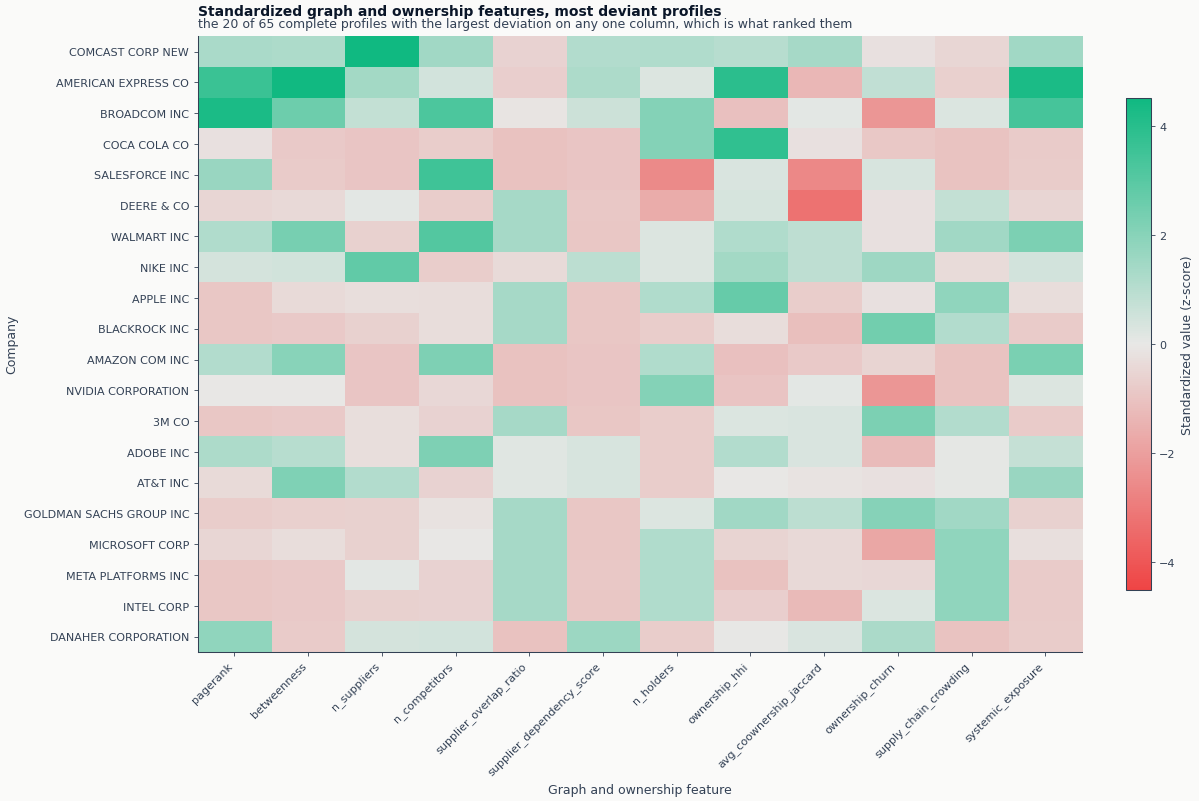

In [43]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
diverging_cmap = LinearSegmentedColormap.from_list("ml4t_diverging", ml4t_diverging())
image = ax.imshow(
    plot_data,
    aspect="auto",
    cmap=diverging_cmap,
    interpolation="nearest",
    vmin=-np.abs(plot_data).max(),
    vmax=np.abs(plot_data).max(),
)
ax.set_yticks(range(len(plot_entities)))
ax.set_yticklabels(plot_entities, fontsize=8)
ax.set_xticks(range(len(diagnostic_cols)))
ax.set_xticklabels(diagnostic_cols, fontsize=8, rotation=45, ha="right")
ax.set_xlabel("Graph and ownership feature")
ax.set_ylabel("Company")
add_message_title(
    ax,
    "Standardized graph and ownership features, most deviant profiles",
    subtitle=(
        f"the {len(plot_entities)} of {heatmap_frame.height} complete profiles with "
        "the largest deviation on any one column, which is what ranked them"
    ),
)
fig.colorbar(image, ax=ax, shrink=0.8, label="Standardized value (z-score)")
show_with_alt(
    fig,
    f"A heatmap of {len(diagnostic_cols)} standardized features across "
    f"{len(plot_entities)} companies, on a diverging scale centred at zero. Rows are "
    f"ordered by their largest absolute deviation, so {plot_entities[extreme_row]} at "
    f"the top carries the strongest cell, {diagnostic_cols[extreme_col]} at "
    f"{plot_data[extreme_row, extreme_col]:+.1f}z. "
    f"{int((np.abs(plot_data) >= 2).sum())} of the {plot_data.size} cells reach two "
    "standard deviations or more; the rest are pale, in both directions.",
)

Combining graph-derived columns (PageRank, betweenness) with 13F holdings
columns (n_holders, ownership_hhi) puts operational structure and ownership on
one row, which neither source expresses alone. Whether these interactions carry
predictive value is not measured here, and the rows on display were selected for
being extreme, so the figure cannot answer it either.

## 12. Persist Outputs

In [44]:
FEATURE_METADATA = {
    "pagerank": {
        "category": "topology",
        "interpretation": "Graph centrality in the supply network",
    },
    "betweenness": {"category": "topology", "interpretation": "Bridge or bottleneck position"},
    "clustering": {"category": "topology", "interpretation": "Local neighborhood density"},
    "in_degree": {"category": "topology", "interpretation": "Incoming graph connections"},
    "out_degree": {"category": "topology", "interpretation": "Outgoing graph connections"},
    "n_suppliers": {"category": "supply", "interpretation": "Number of extracted suppliers"},
    "n_competitors": {"category": "supply", "interpretation": "Number of extracted competitors"},
    "n_customers": {"category": "supply", "interpretation": "Number of extracted customers"},
    "shared_supplier_count": {
        "category": "supply",
        "interpretation": "Suppliers shared with other covered companies",
    },
    "single_source_count": {
        "category": "supply",
        "interpretation": "Suppliers serving only one covered company",
    },
    "supplier_overlap_ratio": {
        "category": "supply",
        "interpretation": "Fraction of suppliers shared across firms",
    },
    "supplier_dependency_score": {
        "category": "supply",
        "interpretation": "Average inverse supplier diversification",
    },
}

Ownership metadata distinguishes measured point-in-time quantities from the
transparent candidate proxies used later.

In [45]:
FEATURE_METADATA.update(
    {
        "n_holders": {
            "category": "holdings",
            "interpretation": "Covered institutions holding the stock",
        },
        "crowding_score": {
            "category": "holdings",
            "interpretation": "Holder count over its median across held securities",
        },
        "top_holder_pct": {
            "category": "holdings",
            "interpretation": "Largest holder share of value",
        },
        "ownership_hhi": {"category": "holdings", "interpretation": "Ownership concentration"},
        "inst_coverage_pct": {
            "category": "holdings",
            "interpretation": "Holder count over the institutions in the 13F panel",
        },
        "inst_value_change": {
            "category": "holdings",
            "interpretation": "Change in institutional value",
        },
        "inst_pct_change": {
            "category": "holdings",
            "interpretation": "Percent change in institutional value",
        },
        "avg_coownership_jaccard": {
            "category": "holdings",
            "interpretation": "Average holder overlap with matched peers",
        },
        "n_similar_stocks": {
            "category": "holdings",
            "interpretation": "Count of matched peers with high holder overlap",
        },
    }
)

Temporal fields separate the zero-baseline supply snapshot from vintage-aware
ownership history.

In [46]:
FEATURE_METADATA.update(
    {
        "relationship_churn": {
            "category": "temporal",
            "interpretation": "Zero baseline until multiple vintages exist",
        },
        "centrality_momentum": {
            "category": "temporal",
            "interpretation": "Zero baseline until multiple vintages exist",
        },
        "supplier_change": {
            "category": "temporal",
            "interpretation": "Zero baseline until multiple vintages exist",
        },
        "ownership_churn": {
            "category": "temporal",
            "interpretation": "1 − mean Jaccard of holder sets across consecutive report periods",
        },
        "position_value_cv": {
            "category": "temporal",
            "interpretation": "Coefficient of variation of position value across report periods",
        },
        "new_holders_recent": {
            "category": "temporal",
            "interpretation": "CIKs holding the stock in the latest report period but not the prior one",
        },
    }
)

Cross-graph metadata describes each interaction algebraically without
implying measured causality or predictive value.

In [47]:
FEATURE_METADATA.update(
    {
        "supply_chain_crowding": {
            "category": "cross_graph",
            "interpretation": "Supplier-overlap ratio × normalized holder count",
        },
        "concentrated_dependency_risk": {
            "category": "cross_graph",
            "interpretation": "Supplier-dependency score × ownership HHI",
        },
        "systemic_exposure": {
            "category": "cross_graph",
            "interpretation": "Betweenness centrality × holder count",
        },
        "customer_concentration_risk": {
            "category": "cross_graph",
            "interpretation": "Customer count × top-holder value share",
        },
    }
)

In [48]:
all_features.write_parquet(OUTPUT_DIR / "features.parquet")
features_long = all_features.unpivot(
    index=["entity", "cusip", "issuer_name"],
    variable_name="feature_name",
    value_name="feature_value",
)
features_long.write_parquet(OUTPUT_DIR / "features_long.parquet")
pl.DataFrame(
    [{"feature_name": key, **value} for key, value in FEATURE_METADATA.items()]
).write_parquet(OUTPUT_DIR / "feature_metadata.parquet")
company_mapping.write_parquet(OUTPUT_DIR / "company_mapping.parquet")

print("Saved: features.parquet")
print("Saved: features_long.parquet")
print("Saved: feature_metadata.parquet")
print("Saved: company_mapping.parquet")

Saved: features.parquet
Saved: features_long.parquet
Saved: feature_metadata.parquet
Saved: company_mapping.parquet


## 13. Verification and Summary

In [49]:
print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 70)
print(f"Supply snapshot {SUPPLY_SNAPSHOT_NAME}: sha256 {SUPPLY_GRAPH_SHA256[:12]}")
print(f"Extraction cache behind it: {str(SUPPLY_SNAPSHOT['cache_content_hash'])[:12]}")
print(f"Supply-chain companies processed: {len(source_companies)}")
print(f"Cross-graph matches: {len(matched_companies)}")
print(
    "Ambiguous issuer mappings: "
    f"{company_mapping.filter(pl.col('match_method') == 'ambiguous').height}"
)
print(f"Supply relationships: {len(supply_rel_df)}")
print(
    f"13F report periods public at {CUTOFF_DATE}: {len(PUBLIC_PERIODS)} "
    f"({PUBLIC_PERIODS[0].isoformat()} to {PUBLIC_PERIODS[-1].isoformat()})"
)
print(f"Feature columns: {len(all_features.columns) - 3}")
print(f"Output target: {OUTPUT_DIR.name}")


NOTEBOOK EXECUTION COMPLETE
Supply snapshot ch23_supply_chain: sha256 ce7a52bf68f1
Extraction cache behind it: b20bdf979f79
Supply-chain companies processed: 106
Cross-graph matches: 65
Ambiguous issuer mappings: 8
Supply relationships: 995
13F report periods public at 2026-05-15: 4 (2025-06-30 to 2026-03-31)
Feature columns: 31
Output target: knowledge_graph_features


## Key Takeaways

1. Network topology features (PageRank, betweenness, clustering) capture
   structural importance and bottleneck risk that standalone entity
   attributes miss.
2. Point-in-time long-equity 13F features summarize holder breadth,
   concentration, and co-ownership; they are candidate crowding proxies, not
   measured price impact. Holder breadth is bounded by the ten institutions in
   the panel, so `n_holders`, `crowding_score` and `inst_coverage_pct` are one
   small integer on three scales rather than three measurements.
3. Cross-graph features combining supply-chain and ownership signals
   create transparent interaction terms for downstream testing.
4. The feature matrix is output in both wide format (ready for gradient
   boosting) and long format (convenient for IC analysis), with ambiguous
   issuer mappings preserved in a separate audit artifact.
5. A consumer verifies its input rather than restating it. The supply graph is
   checked against the identity 02 recorded when it wrote the graph, and that
   record is checked against the extraction cache committed in this repository,
   so no constant here has to be re-copied when 02 changes.
6. The report period is in the artifact, so nothing here has to infer one. An
   earlier revision clustered filing dates within fourteen days to approximate
   a quarter; `report_date` says which quarter each row describes, and the last
   filing date within a period says when that period became knowable.

**Next**: See `10_network_portfolio_construction.py` for network-based
portfolio construction and Section 23.4 for the full feature discussion.